In [12]:
import pandas as pd
from sklearn.manifold import TSNE
import seaborn as sns
import umap
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

In [14]:
mutation = pd.read_csv("data/sample_matrix.txt", sep="\t")
mutation[['gene_symbol', 'Hugo_Symbol']] = mutation['studyID:sampleId'].str.split(':', expand=True)
mutation = mutation[['Hugo_Symbol', 'Altered', 'TP53']]
mutation

,Hugo_Symbol,Altered,TP53
0,SJRH30_SOFT_TISSUE,1,1
1,FADU_UPPER_AERODIGESTIVE_TRACT,1,1
2,HH_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE,1,1
3,SKNMC_BONE,0,0
4,SNU182_LIVER,1,1
...,...,...,...
1565,HUH6CLONE5_LIVER,1,1
1566,CROAP3_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE,0,0
1567,ACN_AUTONOMIC_GANGLIA,1,1
1568,YAMATO_SOFT_TISSUE,1,1


In [15]:
rna = pd.read_csv("data/ccle_broad_2019/data_mrna_seq_rpkm.txt", sep="\t").T.reset_index()
rna.columns = rna.iloc[0]
rna = rna[1:] 
rna

,Hugo_Symbol,DDX11L1,WASH7P,MIR1302-11,FAM138A,OR4G4P,OR4G11P,OR4F5,RP11-34P13.7,CICP27,...,MT-ND3,MT-TR,MT-TH,MT-TS2,MT-TL2,MT-ND5,MT-ND6,MT-TE,MT-CYB,MT-TT
1,22RV1_PROSTATE,0.0,12.63011,0.04289,0.0,0.0,0.0,0.0,0.44714,0.37909,...,1176.81189,0.0,0.0,0.0,0.12335,2393.80298,1825.52332,0.25386,4923.78223,0.0
2,2313287_STOMACH,0.03755,10.14155,0.01037,0.00869,0.0,0.0,0.0,0.34327,0.09168,...,1009.34979,0.0,0.0,0.0,0.0,1960.96802,2056.64697,0.0,3827.00537,0.0
3,253JBV_URINARY_TRACT,0.0,6.20657,0.16955,0.22423,0.02886,0.01939,0.0,0.16982,0.10995,...,2816.78296,0.0,0.39614,0.0,0.51331,1896.2887,2184.88647,0.2641,1905.18481,0.0
4,253J_URINARY_TRACT,0.06507,6.55835,0.23364,0.16558,0.03875,0.03904,0.0,0.08922,0.09146,...,7116.30469,0.14115,0.26594,0.0,1.03378,3522.37695,4568.00195,0.0,4590.01416,0.0
5,42MGBA_CENTRAL_NERVOUS_SYSTEM,0.0,7.61752,0.08765,0.0,0.0,0.0,0.0,0.09428,0.07513,...,1049.68384,0.13768,0.0,0.0,0.25209,1178.93579,1616.96484,0.1297,2343.92407,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1152,UMUC9_URINARY_TRACT,0.03236,8.70551,0.07747,0.0,0.00642,0.0,0.01325,0.02958,0.10214,...,2820.28882,0.0936,0.0,0.0,0.0,1452.41895,996.53717,0.08817,3437.12769,0.0
1153,UPCISCC152_UPPER_AERODIGESTIVE_TRACT,0.0,15.23348,0.07448,0.02674,0.0,0.0,0.0,0.04402,0.08265,...,995.5639,0.16713,0.0,0.0,0.30602,793.5871,593.61139,0.31489,1645.22168,0.0
1154,UW228_CENTRAL_NERVOUS_SYSTEM,0.03799,6.47732,0.01049,0.00879,0.0,0.02279,0.0,0.06945,0.01686,...,441.25647,0.16482,0.0,0.0,0.0,757.41357,472.01627,0.15526,973.56439,0.16232
1155,Y79_AUTONOMIC_GANGLIA,0.02907,8.45568,0.39607,0.26449,0.0,0.01163,0.01191,0.07971,0.09748,...,2341.42505,0.50444,0.2376,0.27787,0.92361,1218.16992,729.65912,0.55439,1221.39954,0.0828


In [17]:
data = pd.merge(mutation, rna, on='Hugo_Symbol', how='inner')
data[['prefix', 'tissue']] = data['Hugo_Symbol'].str.split('_', n=1, expand=True)
data


,Hugo_Symbol,Altered,TP53_x,DDX11L1,WASH7P,MIR1302-11,FAM138A,OR4G4P,OR4G11P,OR4F5,...,MT-TH,MT-TS2,MT-TL2,MT-ND5,MT-ND6,MT-TE,MT-CYB,MT-TT,prefix,tissue
0,FADU_UPPER_AERODIGESTIVE_TRACT,1,1,0.0,5.1835,0.01052,0.0,0.0,0.0,0.0234,...,0.0,0.0,0.0,1317.52258,1196.75122,0.31135,1787.94458,0.0,FADU,UPPER_AERODIGESTIVE_TRACT
1,HH_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE,1,1,0.05643,5.72749,0.25718,0.34596,0.16805,0.13544,0.13002,...,0.11532,0.13487,0.22414,1635.74133,1838.11011,0.23064,2874.67969,0.0,HH,HAEMATOPOIETIC_AND_LYMPHOID_TISSUE
2,SKNMC_BONE,0,0,0.08199,11.74241,0.06793,0.01264,0.0,0.0,0.0,...,0.11169,0.13062,0.32564,1303.24939,1671.89966,0.22338,2865.82617,0.11677,SKNMC,BONE
3,SNU182_LIVER,1,1,0.14469,4.22183,0.11323,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1084.13037,1245.69885,0.0,1161.77368,0.0,SNU182,LIVER
4,BT20_BREAST,1,1,0.36092,7.45707,0.13291,0.0,0.0,0.0,0.0,...,0.09834,0.0,0.09557,1906.21631,2321.45166,0.29501,4161.57129,0.0,BT20,BREAST
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1121,C33A_CERVIX,1,1,0.07761,7.21211,0.25186,0.01346,0.00578,0.02328,0.0,...,0.23788,0.37093,0.84766,2129.98291,1399.54785,0.63435,2283.80151,0.0,C33A,CERVIX
1122,SW982_SOFT_TISSUE,0,0,0.0,5.06211,0.14717,0.01298,0.0,0.0,0.0,...,0.0,0.0,0.11138,512.84479,310.11151,0.22923,668.37408,0.0,SW982,SOFT_TISSUE
1123,GIMEN_AUTONOMIC_GANGLIA,0,0,0.00963,5.40782,0.13299,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0765,663.47522,351.89856,0.23615,1586.69495,0.0823,GIMEN,AUTONOMIC_GANGLIA
1124,YAMATO_SOFT_TISSUE,1,1,0.0,11.81688,0.17586,0.02266,0.01459,0.01469,0.0,...,0.20018,0.0,0.0,1320.84558,564.16779,0.0,1755.82764,0.20928,YAMATO,SOFT_TISSUE


# TSNE
### Andre tuna i params

/opt/anaconda3/envs/bio_env/lib/python3.13/site-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


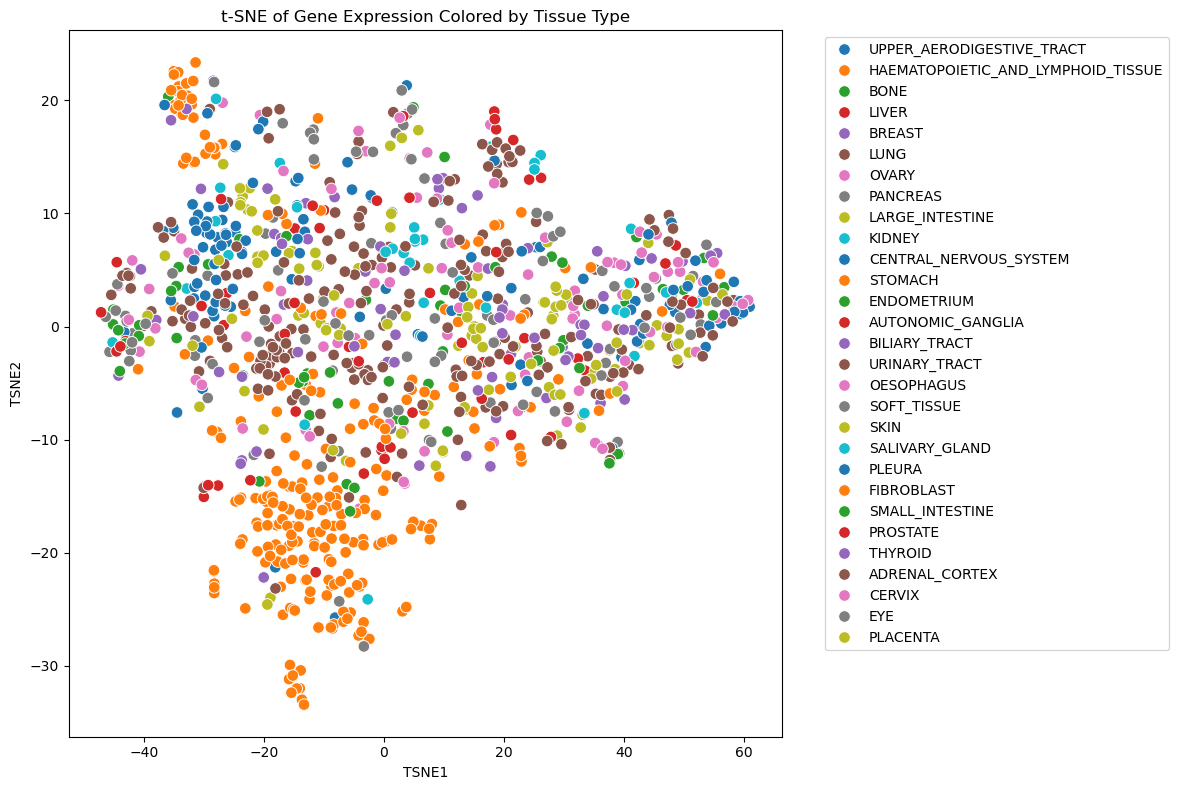

In [18]:
X = data.drop(columns=['Hugo_Symbol', 'Altered','TP53_x', 'prefix', 'tissue']) 
y = data['tissue']

# Step 2: Run t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
X_tsne = tsne.fit_transform(X)

# Step 3: Create a DataFrame with the results
tsne_df = pd.DataFrame({
    'TSNE1': X_tsne[:, 0],
    'TSNE2': X_tsne[:, 1],
    'Tissue': y
})

# Step 4: Plot
plt.figure(figsize=(12, 8))
sns.scatterplot(data=tsne_df, x='TSNE1', y='TSNE2', hue='Tissue', palette='tab10', s=70)
plt.title("t-SNE of Gene Expression Colored by Tissue Type")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


# UMAP
### Andre tuna in params

/opt/anaconda3/envs/bio_env/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


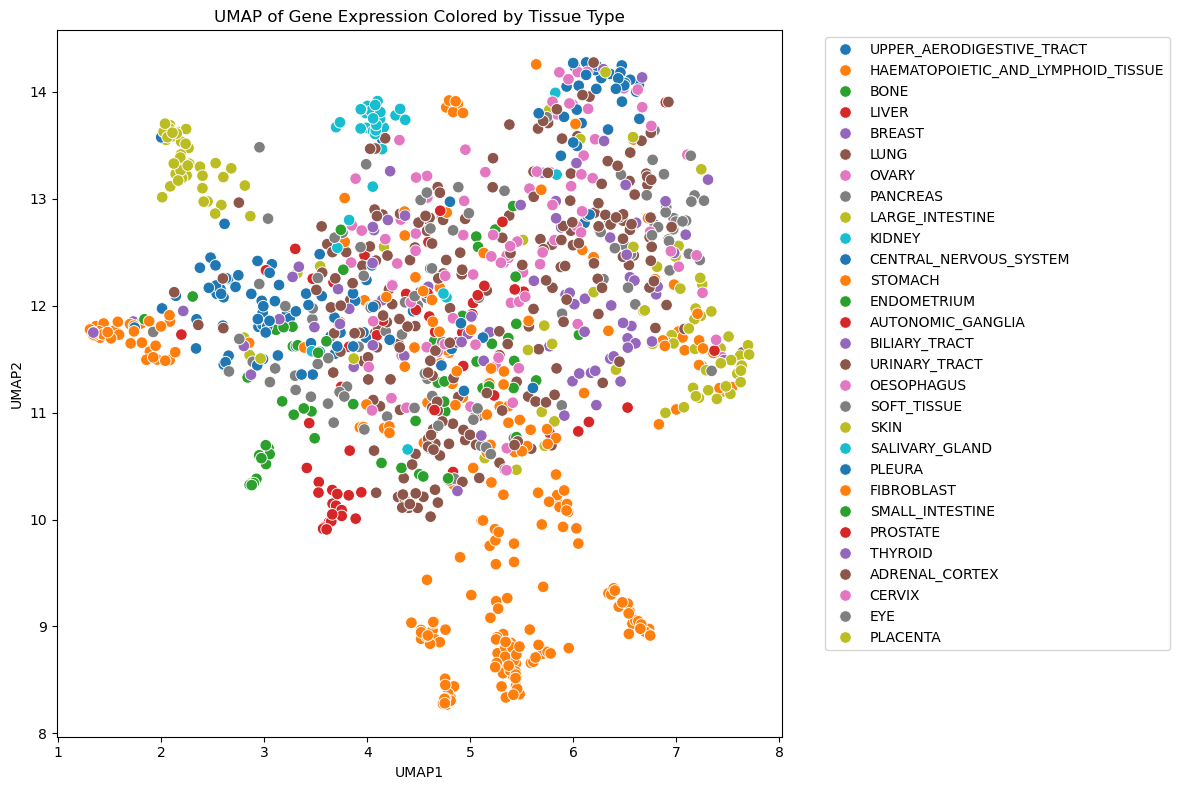

In [19]:
X = data.drop(columns=['Hugo_Symbol', 'Altered','TP53_x', 'prefix', 'tissue']) 
y = data['tissue']

# Optional: Scale the data before UMAP or DBSCAN
X_scaled = StandardScaler().fit_transform(X)

# Step 2: Fit UMAP
reducer = umap.UMAP(n_components=2, random_state=42)
X_umap = reducer.fit_transform(X_scaled)

# Step 3: Create a DataFrame for plotting
umap_df = pd.DataFrame({
    'UMAP1': X_umap[:, 0],
    'UMAP2': X_umap[:, 1],
    'Tissue': y
})

# Step 4: Plot
plt.figure(figsize=(12, 8))
sns.scatterplot(data=umap_df, x='UMAP1', y='UMAP2', hue='Tissue', palette='tab10', s=70)
plt.title("UMAP of Gene Expression Colored by Tissue Type")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


# UMAP + DBSCAN
### Andre tuna i params

In [20]:
y

0                UPPER_AERODIGESTIVE_TRACT
1       HAEMATOPOIETIC_AND_LYMPHOID_TISSUE
2                                     BONE
3                                    LIVER
4                                   BREAST
                       ...                
1121                                CERVIX
1122                           SOFT_TISSUE
1123                     AUTONOMIC_GANGLIA
1124                           SOFT_TISSUE
1125                     AUTONOMIC_GANGLIA
Name: tissue, Length: 1126, dtype: object

C:\Users\Samuele\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\Samuele\AppData\Roaming\Python\Python312\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


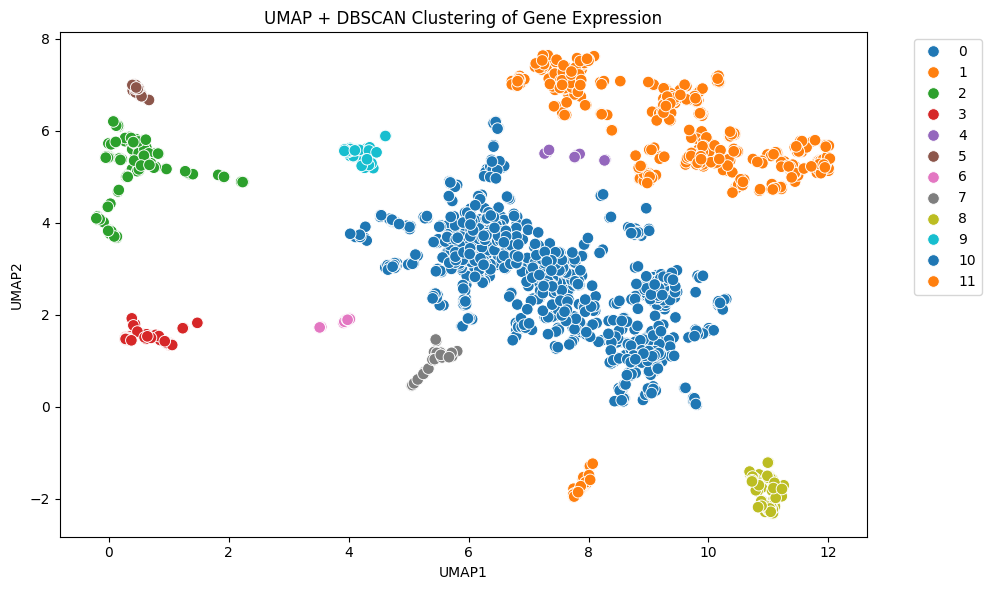

In [8]:
X = data.drop(columns=['Hugo_Symbol', 'Altered','TP53_x', 'prefix', 'tissue']) 
y = data['tissue']

# Optional: Scale the data before UMAP or DBSCAN
X_scaled = StandardScaler().fit_transform(X)

# Step 2: UMAP dimensionality reduction
reducer = umap.UMAP(n_components=2, random_state=42)
X_umap = reducer.fit_transform(X_scaled)

# Step 3: DBSCAN clustering on UMAP output
dbscan = DBSCAN(eps=0.5, min_samples=5)
clusters = dbscan.fit_predict(X_umap)

# Step 4: Create a DataFrame for plotting
umap_df = pd.DataFrame({
    'UMAP1': X_umap[:, 0],
    'UMAP2': X_umap[:, 1],
    'Cluster': clusters,
    'Tissue': y
})

# Step 5: Plot results
plt.figure(figsize=(10, 6))
sns.scatterplot(data=umap_df, x='UMAP1', y='UMAP2', hue='Cluster', palette='tab10', s=70)
plt.title("UMAP + DBSCAN Clustering of Gene Expression")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [9]:
umap_df.groupby('Cluster')['Tissue'].value_counts()

Cluster  Tissue                            
0        LUNG                                  273
         CENTRAL_NERVOUS_SYSTEM                117
         HAEMATOPOIETIC_AND_LYMPHOID_TISSUE     84
         SOFT_TISSUE                            68
         OVARY                                  67
                                              ... 
11       CENTRAL_NERVOUS_SYSTEM                  3
         BONE                                    2
         HAEMATOPOIETIC_AND_LYMPHOID_TISSUE      2
         AUTONOMIC_GANGLIA                       1
         SOFT_TISSUE                             1
Name: count, Length: 75, dtype: int64